Models:
- Logistic Regression
- Tree Decision
- Random Forest
- CatBoost
- XGBoost

For imbalance fix:
- `class-weight`
- `undersampling` & `oversampling`
- `SMOTE`

In [1]:
import pandas as pd
import numpy as np

from sklearn.linear_model import LogisticRegression
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from imblearn.over_sampling import SMOTENC
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler
from imblearn.pipeline import Pipeline as ImbPipeline

from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.frozen import FrozenEstimator
from sklearn.model_selection import GridSearchCV

from sklearn.metrics import (precision_score,
                             recall_score,
                             average_precision_score,
                             f1_score)

import joblib

In [2]:
RANDOM_SEED = 42
df = pd.read_csv('../data/Synthetic_Financial_datasets_log.csv')

## New Features

In [3]:
df['log_amount'] = np.log1p(df['amount'])
df['day'] = (df['step'] - 1) // 24
df['hour'] = (df['step'] - 1) % 24
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)

features = ['step', 'type',
            'amount', 'log_amount',
            'day', 'hour_sin',
            'hour_cos']

target = ['isFraud']

df = df[features + target]

In [4]:
test_point = 550
calibration_point = test_point - 50
validation_point = calibration_point - 100

test = df[df['step'] > test_point].copy()
calibration = df[(df['step'] <= test_point) & (df['step'] > calibration_point)].copy()
validation = df[(df['step'] <= calibration_point) & (df['step'] > validation_point)].copy()
train = df[df['step'] <= validation_point].copy()

In [5]:
X_train, y_train = train.drop('isFraud', axis=1), train['isFraud']
X_val, y_val = validation.drop('isFraud', axis=1), validation['isFraud']
X_cal, y_cal = calibration.drop('isFraud', axis=1), calibration['isFraud']
X_test, y_test = test.drop('isFraud', axis=1), test['isFraud']

# For SMOTENC
X_train['type'] = X_train['type'].astype('category')

In [6]:
categorial_features = ['type']
numeric_features = ['amount', 'log_amount']
other_features =['step', 'day', 'hour_sin', 'hour_cos']

## Pipelines

### Logistic Regression

#### Logistic Regression Preprocessing

In [7]:
log_reg_preprocessor = ColumnTransformer(transformers=[
    ('numeric', StandardScaler(), numeric_features),
    ('categorical', OneHotEncoder(), categorial_features),
    ('others', 'passthrough', other_features)
])

#### Logistic Regression Pipelines

In [8]:
log_reg_pipelines = {
    'base': Pipeline(steps=[
        ('preprocessor', log_reg_preprocessor),
        ('classifier', LogisticRegression(
            max_iter=1000,
            random_state=RANDOM_SEED)
        )
    ]),

    'balanced': Pipeline(steps=[
        ('preprocessor', log_reg_preprocessor),
        ('classifier', LogisticRegression(
            max_iter=1000,
            class_weight='balanced',
            random_state=RANDOM_SEED)
        )
    ]),

    # UnderSampling
    'under.05': ImbPipeline(steps=[
        ('preprocessor', log_reg_preprocessor),
        ('undersampling', RandomUnderSampler(
            sampling_strategy=0.05,
            random_state=RANDOM_SEED)),
        ('classifier', LogisticRegression(
            max_iter=1000,
            class_weight='balanced',
            random_state=RANDOM_SEED)
        )
    ]),

    'under.10': ImbPipeline(steps=[
        ('preprocessor', log_reg_preprocessor),
        ('undersampling', RandomUnderSampler(
            sampling_strategy=0.10,
            random_state=RANDOM_SEED)),
        ('classifier', LogisticRegression(
            max_iter=1000,
            class_weight='balanced',
            random_state=RANDOM_SEED)
        )
    ]),

    'under.20': ImbPipeline(steps=[
        ('preprocessor', log_reg_preprocessor),
        ('undersampling', RandomUnderSampler(
            sampling_strategy=0.20,
            random_state=RANDOM_SEED)),
        ('classifier', LogisticRegression(
            max_iter=1000,
            class_weight='balanced',
            random_state=RANDOM_SEED)
        )
    ]),

    # OverSampling
    'over.005': ImbPipeline(steps=[
        ('preprocessor', log_reg_preprocessor),
        ('undersampling', RandomOverSampler(
            sampling_strategy=0.005,
            random_state=RANDOM_SEED)),
        ('classifier', LogisticRegression(
            max_iter=1000,
            class_weight='balanced',
            random_state=RANDOM_SEED)
        )
    ]),

    'over.01': ImbPipeline(steps=[
        ('preprocessor', log_reg_preprocessor),
        ('undersampling', RandomOverSampler(
            sampling_strategy=0.01,
            random_state=RANDOM_SEED)),
        ('classifier', LogisticRegression(
            max_iter=1000,
            class_weight='balanced',
            random_state=RANDOM_SEED)
        )
    ]),

    'over.02': ImbPipeline(steps=[
        ('preprocessor', log_reg_preprocessor),
        ('undersampling', RandomOverSampler(
            sampling_strategy=0.02,
            random_state=RANDOM_SEED)),
        ('classifier', LogisticRegression(
            max_iter=1000,
            class_weight='balanced',
            random_state=RANDOM_SEED)
        )
    ]),

    # SMOTE
    'smote.01': ImbPipeline(steps=[
        ('smote', SMOTENC(
            categorical_features=categorial_features,
            sampling_strategy=0.01,
            random_state=RANDOM_SEED,
            k_neighbors=5
        )),
        ('preprocessor', log_reg_preprocessor),
        ('classifier', LogisticRegression(
            max_iter=1000,
            class_weight='balanced',
            random_state=RANDOM_SEED)
        )
    ]),

    'smote.02': ImbPipeline(steps=[
        ('smote', SMOTENC(
            categorical_features=categorial_features,
            sampling_strategy=0.02,
            random_state=RANDOM_SEED,
            k_neighbors=5
        )),
        ('preprocessor', log_reg_preprocessor),
        ('classifier', LogisticRegression(
            max_iter=1000,
            class_weight='balanced',
            random_state=RANDOM_SEED)
        )
    ]),
}

### Decision Tree Classifier

#### Decision Tree Preprocessor

In [9]:
dt_preprocessor = ColumnTransformer(transformers=[
    ('numeric', StandardScaler(), numeric_features),
    ('categorical', OneHotEncoder(), categorial_features),
    ('others', 'passthrough', other_features)
])

#### Decision Tree Pipelines

In [10]:
dt_pipelines = {

    # base
    'base': Pipeline(steps=[
        ('preprocessor', dt_preprocessor),
        ('classifier', DecisionTreeClassifier(
            max_depth=15,
            random_state=RANDOM_SEED
        ))
    ]),

    # balanced
    'balanced': Pipeline(steps=[
        ('preprocessor', dt_preprocessor),
        ('classifier', DecisionTreeClassifier(
            class_weight='balanced',
            max_depth=15,
            random_state=RANDOM_SEED
        ))
    ]),


    # UnderSampling
    'under.05': ImbPipeline(steps=[
        ('preprocessor', dt_preprocessor),
        ('undersampling', RandomUnderSampler(
            sampling_strategy=0.05,
            random_state=RANDOM_SEED)),
        ('classifier', DecisionTreeClassifier(
            class_weight='balanced',
            max_depth=15,
            random_state=RANDOM_SEED
        ))
    ]),

    'under.10': ImbPipeline(steps=[
        ('preprocessor', dt_preprocessor),
        ('undersampling', RandomUnderSampler(
            sampling_strategy=0.10,
            random_state=RANDOM_SEED)),
        ('classifier', DecisionTreeClassifier(
            class_weight='balanced',
            max_depth=15,
            random_state=RANDOM_SEED
        ))
    ]),

    'under.20': ImbPipeline(steps=[
        ('preprocessor', dt_preprocessor),
        ('undersampling', RandomUnderSampler(
            sampling_strategy=0.20,
            random_state=RANDOM_SEED)),
        ('classifier', DecisionTreeClassifier(
            class_weight='balanced',
            max_depth=15,
            random_state=RANDOM_SEED
        ))
    ]),

    # OverSampling
    'over.005': ImbPipeline(steps=[
        ('preprocessor', dt_preprocessor),
        ('undersampling', RandomOverSampler(
            sampling_strategy=0.005,
            random_state=RANDOM_SEED)),
        ('classifier', DecisionTreeClassifier(
            class_weight='balanced',
            max_depth=15,
            random_state=RANDOM_SEED
        ))
    ]),

    'over.01': ImbPipeline(steps=[
        ('preprocessor', dt_preprocessor),
        ('undersampling', RandomOverSampler(
            sampling_strategy=0.01,
            random_state=RANDOM_SEED)),
        ('classifier', DecisionTreeClassifier(
            class_weight='balanced',
            max_depth=15,
            random_state=RANDOM_SEED
        ))
    ]),

    'over.02': ImbPipeline(steps=[
        ('preprocessor', dt_preprocessor),
        ('undersampling', RandomOverSampler(
            sampling_strategy=0.02,
            random_state=RANDOM_SEED)),
        ('classifier', DecisionTreeClassifier(
            class_weight='balanced',
            max_depth=15,
            random_state=RANDOM_SEED
        ))
    ]),

    # SMOTE
    'smote.01': ImbPipeline(steps=[
        ('smote', SMOTENC(
            categorical_features=categorial_features,
            sampling_strategy=0.01,
            random_state=RANDOM_SEED,
            k_neighbors=5
        )),
        ('preprocessor', dt_preprocessor),
        ('classifier', DecisionTreeClassifier(
            class_weight='balanced',
            max_depth=15,
            random_state=RANDOM_SEED
        ))
    ]),

    'smote.02': ImbPipeline(steps=[
        ('smote', SMOTENC(
            categorical_features=categorial_features,
            sampling_strategy=0.02,
            random_state=RANDOM_SEED,
            k_neighbors=5
        )),
        ('preprocessor', dt_preprocessor),
        ('classifier', DecisionTreeClassifier(
            class_weight='balanced',
            max_depth=15,
            random_state=RANDOM_SEED
        ))
    ]),
}

### Random Forest

#### Random Forest Preprocessor

In [ ]:
rf_preprocessor = ColumnTransformer(transformers=[
    ('numeric', StandardScaler(), numeric_features),
    ('categorical', OneHotEncoder(), categorial_features),
    ('others', 'passthrough', other_features)
])

#### Random Forest Pipelines

In [ ]:
rf_pipelines = {

    # base
    'base': Pipeline(steps=[
        ('preprocessor', rf_preprocessor),
        ('classifier', RandomForestClassifier(
            max_depth=15,
            random_state=RANDOM_SEED
        ))
    ]),

    # balanced
    'balanced': Pipeline(steps=[
        ('preprocessor', rf_preprocessor),
        ('classifier', RandomForestClassifier(
            class_weight='balanced',
            max_depth=15,
            random_state=RANDOM_SEED
        ))
    ]),


    # UnderSampling
    'under.05': ImbPipeline(steps=[
        ('preprocessor', rf_preprocessor),
        ('undersampling', RandomUnderSampler(
            sampling_strategy=0.05,
            random_state=RANDOM_SEED)),
        ('classifier', RandomForestClassifier(
            class_weight='balanced',
            max_depth=15,
            random_state=RANDOM_SEED
        ))
    ]),

    'under.10': ImbPipeline(steps=[
        ('preprocessor', rf_preprocessor),
        ('undersampling', RandomUnderSampler(
            sampling_strategy=0.10,
            random_state=RANDOM_SEED)),
        ('classifier', RandomForestClassifier(
            class_weight='balanced',
            max_depth=15,
            random_state=RANDOM_SEED
        ))
    ]),

    'under.20': ImbPipeline(steps=[
        ('preprocessor', rf_preprocessor),
        ('undersampling', RandomUnderSampler(
            sampling_strategy=0.20,
            random_state=RANDOM_SEED)),
        ('classifier', RandomForestClassifier(
            class_weight='balanced',
            max_depth=15,
            random_state=RANDOM_SEED
        ))
    ]),

    # OverSampling
    'over.005': ImbPipeline(steps=[
        ('preprocessor', rf_preprocessor),
        ('undersampling', RandomOverSampler(
            sampling_strategy=0.005,
            random_state=RANDOM_SEED)),
        ('classifier', RandomForestClassifier(
            class_weight='balanced',
            max_depth=15,
            random_state=RANDOM_SEED
        ))
    ]),

    'over.01': ImbPipeline(steps=[
        ('preprocessor', rf_preprocessor),
        ('undersampling', RandomOverSampler(
            sampling_strategy=0.01,
            random_state=RANDOM_SEED)),
        ('classifier', RandomForestClassifier(
            class_weight='balanced',
            max_depth=15,
            random_state=RANDOM_SEED
        ))
    ]),

    'over.02': ImbPipeline(steps=[
        ('preprocessor', rf_preprocessor),
        ('undersampling', RandomOverSampler(
            sampling_strategy=0.02,
            random_state=RANDOM_SEED)),
        ('classifier', RandomForestClassifier(
            class_weight='balanced',
            max_depth=15,
            random_state=RANDOM_SEED
        ))
    ]),

    # SMOTE
    'smote.01': ImbPipeline(steps=[
        ('smote', SMOTENC(
            categorical_features=categorial_features,
            sampling_strategy=0.01,
            random_state=RANDOM_SEED,
            k_neighbors=5
        )),
        ('preprocessor', rf_preprocessor),
        ('classifier', RandomForestClassifier(
            class_weight='balanced',
            max_depth=15,
            random_state=RANDOM_SEED
        ))
    ]),

    'smote.02': ImbPipeline(steps=[
        ('smote', SMOTENC(
            categorical_features=categorial_features,
            sampling_strategy=0.02,
            random_state=RANDOM_SEED,
            k_neighbors=5
        )),
        ('preprocessor', rf_preprocessor),
        ('classifier', RandomForestClassifier(
            class_weight='balanced',
            max_depth=15,
            random_state=RANDOM_SEED
        ))
    ]),
}

### XGBoost

#### XGBoost Preprocessor

In [ ]:
xgb_preprocessor = ColumnTransformer(transformers=[
    ('numeric', StandardScaler(), numeric_features),
    ('categorical', OneHotEncoder(), categorial_features),
    ('others', 'passthrough', other_features)
])

#### XGBoost Pipelines

In [ ]:
xgb_pipelines = {

    # base
    'base': Pipeline(steps=[
        ('preprocessor', xgb_preprocessor),
        ('classifier', XGBClassifier(
            random_state=RANDOM_SEED
        ))
    ]),


    # UnderSampling
    'under.05': ImbPipeline(steps=[
        ('preprocessor', xgb_preprocessor),
        ('undersampling', RandomUnderSampler(
            sampling_strategy=0.05,
            random_state=RANDOM_SEED)),
        ('classifier', XGBClassifier(
            random_state=RANDOM_SEED
        ))
    ]),

    'under.10': ImbPipeline(steps=[
        ('preprocessor', xgb_preprocessor),
        ('undersampling', RandomUnderSampler(
            sampling_strategy=0.10,
            random_state=RANDOM_SEED)),
        ('classifier', XGBClassifier(
            random_state=RANDOM_SEED
        ))
    ]),

    'under.20': ImbPipeline(steps=[
        ('preprocessor', xgb_preprocessor),
        ('undersampling', RandomUnderSampler(
            sampling_strategy=0.20,
            random_state=RANDOM_SEED)),
        ('classifier', XGBClassifier(
            random_state=RANDOM_SEED
        ))
    ]),

    # OverSampling
    'over.005': ImbPipeline(steps=[
        ('preprocessor', xgb_preprocessor),
        ('undersampling', RandomOverSampler(
            sampling_strategy=0.005,
            random_state=RANDOM_SEED)),
        ('classifier', XGBClassifier(
            random_state=RANDOM_SEED
        ))
    ]),

    'over.01': ImbPipeline(steps=[
        ('preprocessor', xgb_preprocessor),
        ('undersampling', RandomOverSampler(
            sampling_strategy=0.01,
            random_state=RANDOM_SEED)),
        ('classifier', XGBClassifier(
            random_state=RANDOM_SEED
        ))
    ]),

    'over.02': ImbPipeline(steps=[
        ('preprocessor', xgb_preprocessor),
        ('undersampling', RandomOverSampler(
            sampling_strategy=0.02,
            random_state=RANDOM_SEED)),
        ('classifier', XGBClassifier(
            random_state=RANDOM_SEED
        ))
    ]),

    # SMOTE
    'smote.01': ImbPipeline(steps=[
        ('smote', SMOTENC(
            categorical_features=categorial_features,
            sampling_strategy=0.01,
            random_state=RANDOM_SEED,
            k_neighbors=5
        )),
        ('preprocessor', xgb_preprocessor),
        ('classifier', XGBClassifier(
            random_state=RANDOM_SEED
        ))
    ]),

    'smote.02': ImbPipeline(steps=[
        ('smote', SMOTENC(
            categorical_features=categorial_features,
            sampling_strategy=0.02,
            random_state=RANDOM_SEED,
            k_neighbors=5
        )),
        ('preprocessor', xgb_preprocessor),
        ('classifier', XGBClassifier(
            random_state=RANDOM_SEED
        ))
    ]),
}

### Catboost

#### Catboost Preprocessor

In [ ]:
cb_preprocessor = ColumnTransformer(transformers=[
    ('numeric', StandardScaler(), numeric_features),
    ('others', 'passthrough', other_features)
])

#### Catboost Pipelines

In [ ]:
cb_pipelines = {

    # base
    'base': Pipeline(steps=[
        ('preprocessor', cb_preprocessor),
        ('classifier', CatBoostClassifier(
            cat_features=categorial_features,
            verbose=False,
            random_state=RANDOM_SEED
        ))
    ]),


    # UnderSampling
    'under.05': ImbPipeline(steps=[
        ('preprocessor', cb_preprocessor),
        ('undersampling', RandomUnderSampler(
            sampling_strategy=0.05,
            random_state=RANDOM_SEED)),
        ('classifier', CatBoostClassifier(
            cat_features=categorial_features,
            verbose=False,
            random_state=RANDOM_SEED
        ))
    ]),

    'under.10': ImbPipeline(steps=[
        ('preprocessor', cb_preprocessor),
        ('undersampling', RandomUnderSampler(
            sampling_strategy=0.10,
            random_state=RANDOM_SEED)),
        ('classifier', CatBoostClassifier(
            cat_features=categorial_features,
            verbose=False,
            random_state=RANDOM_SEED
        ))
    ]),

    'under.20': ImbPipeline(steps=[
        ('preprocessor', cb_preprocessor),
        ('undersampling', RandomUnderSampler(
            sampling_strategy=0.20,
            random_state=RANDOM_SEED)),
        ('classifier', CatBoostClassifier(
            cat_features=categorial_features,
            verbose=False,
            random_state=RANDOM_SEED
        ))
    ]),

    # OverSampling
    'over.005': ImbPipeline(steps=[
        ('preprocessor', cb_preprocessor),
        ('undersampling', RandomOverSampler(
            sampling_strategy=0.005,
            random_state=RANDOM_SEED)),
        ('classifier', CatBoostClassifier(
            cat_features=categorial_features,
            verbose=False,
            random_state=RANDOM_SEED
        ))
    ]),

    'over.01': ImbPipeline(steps=[
        ('preprocessor', cb_preprocessor),
        ('undersampling', RandomOverSampler(
            sampling_strategy=0.01,
            random_state=RANDOM_SEED)),
        ('classifier', CatBoostClassifier(
            cat_features=categorial_features,
            verbose=False,
            random_state=RANDOM_SEED
        ))
    ]),

    'over.02': ImbPipeline(steps=[
        ('preprocessor', cb_preprocessor),
        ('undersampling', RandomOverSampler(
            sampling_strategy=0.02,
            random_state=RANDOM_SEED)),
        ('classifier', CatBoostClassifier(
            cat_features=categorial_features,
            verbose=False,
            random_state=RANDOM_SEED
        ))
    ]),

    # SMOTE
    'smote.01': ImbPipeline(steps=[
        ('smote', SMOTENC(
            categorical_features=categorial_features,
            sampling_strategy=0.01,
            random_state=RANDOM_SEED,
            k_neighbors=5
        )),
        ('preprocessor', cb_preprocessor),
        ('classifier', CatBoostClassifier(
            cat_features=categorial_features,
            verbose=False,
            random_state=RANDOM_SEED
        ))
    ]),

    'smote.02': ImbPipeline(steps=[
        ('smote', SMOTENC(
            categorical_features=categorial_features,
            sampling_strategy=0.02,
            random_state=RANDOM_SEED,
            k_neighbors=5
        )),
        ('preprocessor', cb_preprocessor),
        ('classifier', CatBoostClassifier(
            cat_features=categorial_features,
            verbose=False,
            random_state=RANDOM_SEED
        ))
    ]),
}

In [11]:
pipelines = {
    'Logistic Regression': log_reg_pipelines,
    'Decision Tree': dt_pipelines,
    # 'Random Forest': rf_pipelines
    # 'XGBoost': xgb_pipelines,
    # 'Catboost': cb_pipelines
}

In [12]:
res_val_table = pd.DataFrame(
    columns=[
        'model',
        'sampling',
        'precision',
        'recall',
        'f1',
        'average_precision'
    ]
)

In [13]:
def estimate_model(y_true, y_proba):
    y_pred = (y_proba >= 0.5).astype(int)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    average_precision = average_precision_score(y_true, y_proba)

    return {
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'average_precision': average_precision,
    }

In [14]:
for name, pipeline in pipelines.items():
    for sampling_name, model in pipeline.items():
        model.fit(X_train, y_train)
        y_proba = model.predict_proba(X_val)[:, 1]
        metrics = estimate_model(y_val, y_proba)
        metrics['model'] = name
        metrics['sampling'] = sampling_name

        res_val_table = pd.concat([res_val_table, pd.DataFrame([metrics])], ignore_index=True)

In [15]:
res_val_table

,model,sampling,precision,recall,f1,average_precision
0,Logistic Regression,base,1.0,0.00738,0.014652,0.250262
1,Logistic Regression,balanced,0.028513,0.830258,0.055132,0.216823
2,Logistic Regression,under.05,0.028603,0.835793,0.055313,0.212327
3,Logistic Regression,under.10,0.028347,0.835793,0.054834,0.215105
4,Logistic Regression,under.20,0.028551,0.835793,0.055215,0.21447
5,Logistic Regression,over.005,0.027744,0.835793,0.053705,0.216073
6,Logistic Regression,over.01,0.02789,0.835793,0.053978,0.215863
7,Logistic Regression,over.02,0.028198,0.833026,0.054549,0.216726
8,Logistic Regression,smote.01,0.027174,0.667897,0.052223,0.08503
9,Logistic Regression,smote.02,0.02711,0.650369,0.052051,0.081467


RESULTS

Logistic Regression & Decision Tree

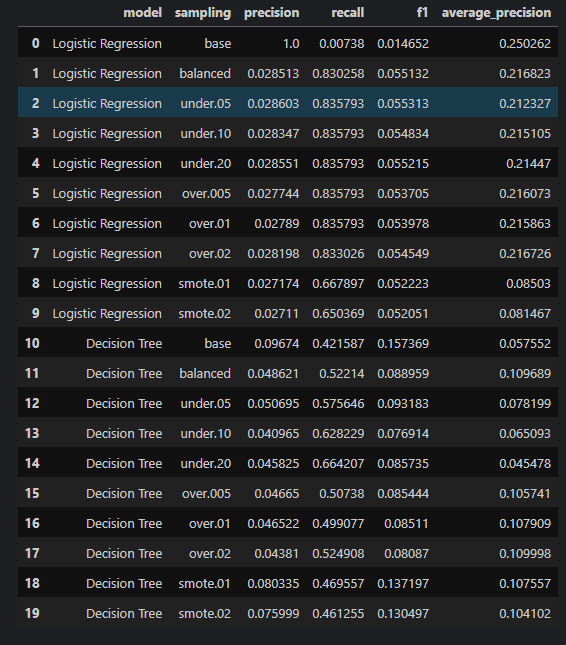
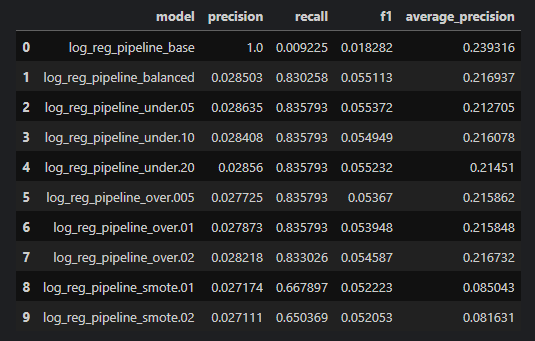
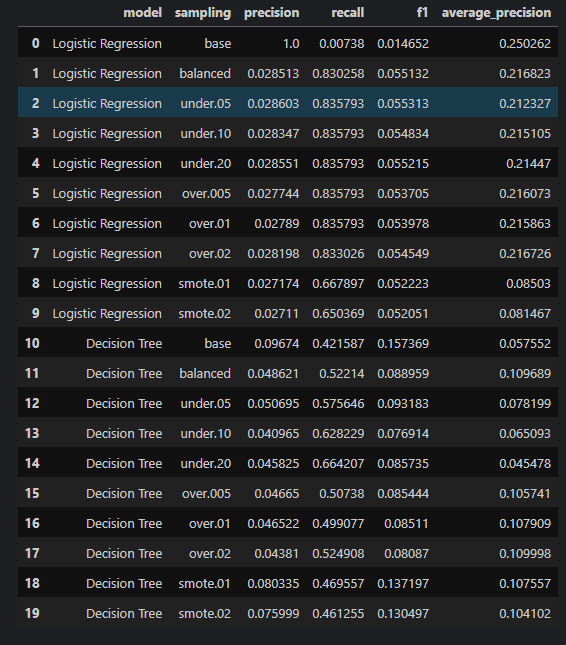